# Artificial Neural Networks — Alphabet Classification
**Objective:** Build, tune, and evaluate an ANN model to classify 26 alphabet letters using 16 image-feature attributes from `Alphabets_data.csv`.

**Dataset:** `Alphabets_data.csv` — 20,000 samples | 16 features | 26 classes (A–Z)

---
## 0. Import Libraries

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

tf.get_logger().setLevel('ERROR')
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

plt.style.use('seaborn-v0_8-whitegrid')
print('TensorFlow version:', tf.__version__)
print('All libraries loaded.')

I0000 00:00:1776316707.232892   23473 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


I0000 00:00:1776316712.031761   23473 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


TensorFlow version: 2.21.0
All libraries loaded.


---
## Task 1 — Data Exploration & Preprocessing

In [2]:
# Load dataset
df = pd.read_csv('Alphabets_data.csv')
print('Shape:', df.shape)
df.head(10)

Shape: (20000, 17)


,letter,xbox,ybox,width,height,onpix,xbar,ybar,x2bar,y2bar,xybar,x2ybar,xy2bar,xedge,xedgey,yedge,yedgex
0,T,2,8,3,5,1,8,13,0,6,6,10,8,0,8,0,8
1,I,5,12,3,7,2,10,5,5,4,13,3,9,2,8,4,10
2,D,4,11,6,8,6,10,6,2,6,10,3,7,3,7,3,9
3,N,7,11,6,6,3,5,9,4,6,4,4,10,6,10,2,8
4,G,2,1,3,1,1,8,6,6,6,6,5,9,1,7,5,10
5,S,4,11,5,8,3,8,8,6,9,5,6,6,0,8,9,7
6,B,4,2,5,4,4,8,7,6,6,7,6,6,2,8,7,10
7,A,1,1,3,2,1,8,2,2,2,8,2,8,1,6,2,7
8,J,2,2,4,4,2,10,6,2,6,12,4,8,1,6,1,7
9,M,11,15,13,9,7,13,2,6,2,12,1,9,8,1,1,8


In [3]:
# Dataset summary
print('='*55)
print('DATASET SUMMARY')
print('='*55)
print(f'  Total Samples  : {df.shape[0]:,}')
print(f'  Total Features : {df.shape[1]-1}')
print(f'  Target Column  : letter (A to Z)')
print(f'  Classes        : {df["letter"].nunique()} unique letters')
print(f'  Missing Values : {df.isnull().sum().sum()}')
print()
feat_desc = {
    'xbox':'Horizontal position of bounding box','ybox':'Vertical position of bounding box',
    'width':'Width of bounding box','height':'Height of bounding box',
    'onpix':'Total on pixels','xbar':'Mean x of on pixels',
    'ybar':'Mean y of on pixels','x2bar':'Mean x² of on pixels',
    'y2bar':'Mean y² of on pixels','xybar':'Mean x·y of on pixels',
    'x2ybar':'Mean x²·y of on pixels','xy2bar':'Mean x·y² of on pixels',
    'xedge':'Mean edge count left→right','xedgey':'Correlation of xedge with y',
    'yedge':'Mean edge count bottom→top','yedgex':'Correlation of yedge with x'
}
pd.DataFrame.from_dict(feat_desc, orient='index', columns=['Description'])

DATASET SUMMARY
  Total Samples  : 20,000
  Total Features : 16
  Target Column  : letter (A to Z)
  Classes        : 26 unique letters
  Missing Values : 0



,Description
xbox,Horizontal position of bounding box
ybox,Vertical position of bounding box
width,Width of bounding box
height,Height of bounding box
onpix,Total on pixels
xbar,Mean x of on pixels
ybar,Mean y of on pixels
x2bar,Mean x² of on pixels
y2bar,Mean y² of on pixels
xybar,Mean x·y of on pixels


In [4]:
# Statistical summary
feature_cols = df.columns[1:].tolist()
df[feature_cols].describe().round(3)

,xbox,ybox,width,height,onpix,xbar,ybar,x2bar,y2bar,xybar,x2ybar,xy2bar,xedge,xedgey,yedge,yedgex
count,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000,20000.000
mean,4.024,7.036,5.122,5.372,3.506,6.898,7.500,4.629,5.179,8.282,6.454,7.929,3.046,8.339,3.692,7.801
std,1.913,3.305,2.015,2.261,2.190,2.026,2.325,2.700,2.381,2.488,2.631,2.081,2.333,1.547,2.567,1.617
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,3.000,5.000,4.000,4.000,2.000,6.000,6.000,3.000,4.000,7.000,5.000,7.000,1.000,8.000,2.000,7.000
50%,4.000,7.000,5.000,6.000,3.000,7.000,7.000,4.000,5.000,8.000,6.000,8.000,3.000,8.000,3.000,8.000
75%,5.000,9.000,6.000,7.000,5.000,8.000,9.000,6.000,7.000,10.000,8.000,9.000,4.000,9.000,5.000,9.000
max,15.000,15.000,15.000,15.000,15.000,15.000,15.000,15.000,15.000,15.000,15.000,15.000,15.000,15.000,15.000,15.000


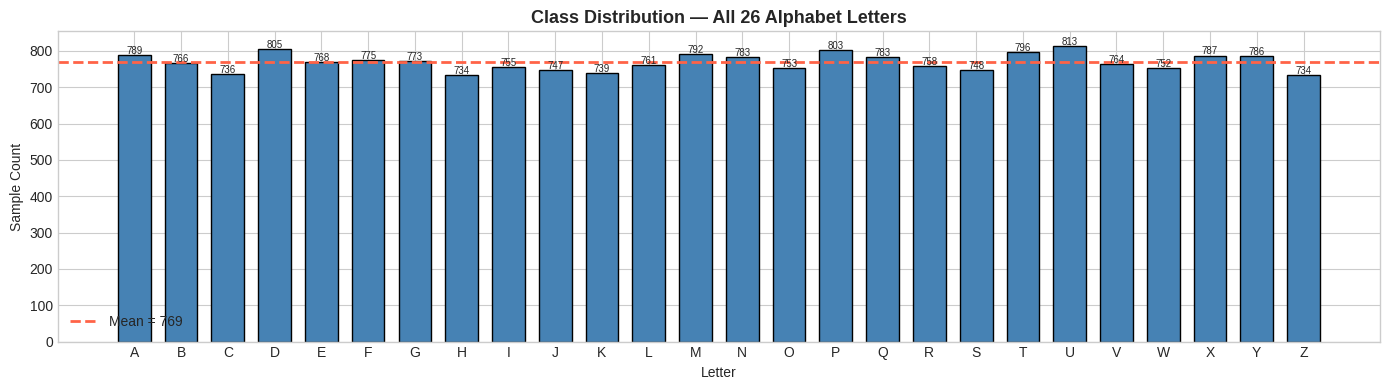

Min: 734 (H)  Max: 813 (U)
Dataset is well-balanced across all 26 classes.


In [5]:
# --- Class distribution ---
class_counts = df['letter'].value_counts().sort_index()

plt.figure(figsize=(14, 4))
bars = plt.bar(class_counts.index, class_counts.values,
               color='steelblue', edgecolor='black', width=0.7)
plt.axhline(class_counts.mean(), color='tomato', linestyle='--',
            linewidth=2, label=f'Mean = {class_counts.mean():.0f}')
for bar, v in zip(bars, class_counts.values):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+3,
             str(v), ha='center', fontsize=7)
plt.title('Class Distribution — All 26 Alphabet Letters',
          fontsize=13, fontweight='bold')
plt.xlabel('Letter')
plt.ylabel('Sample Count')
plt.legend()
plt.tight_layout()
plt.show()
print(f'Min: {class_counts.min()} ({class_counts.idxmin()})  '
      f'Max: {class_counts.max()} ({class_counts.idxmax()})')
print('Dataset is well-balanced across all 26 classes.')

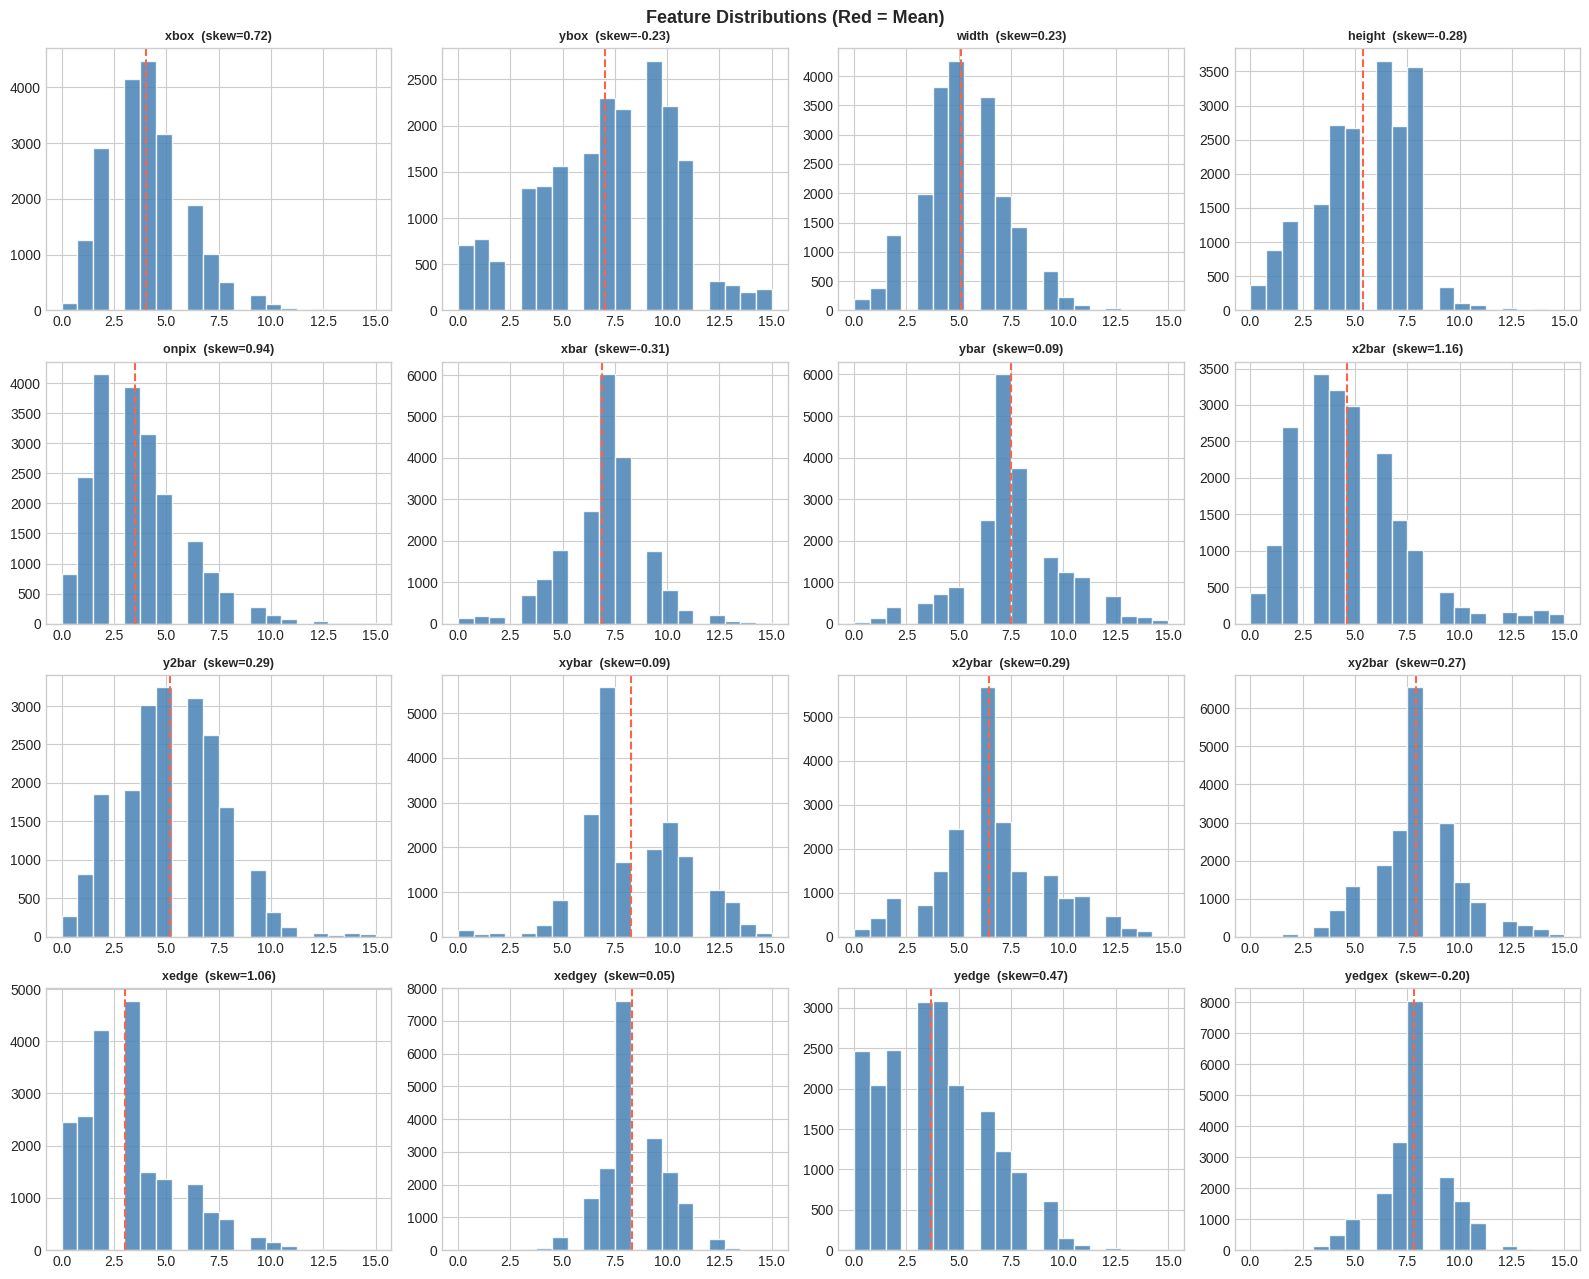

In [6]:
# --- Feature distributions ---
fig, axes = plt.subplots(4, 4, figsize=(16, 13))
axes = axes.flatten()
for i, col in enumerate(feature_cols):
    axes[i].hist(df[col], bins=20, color='steelblue',
                 edgecolor='white', alpha=0.85)
    axes[i].axvline(df[col].mean(), color='tomato',
                    linestyle='--', linewidth=1.5)
    axes[i].set_title(f'{col}  (skew={df[col].skew():.2f})',
                      fontsize=9, fontweight='bold')
plt.suptitle('Feature Distributions (Red = Mean)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

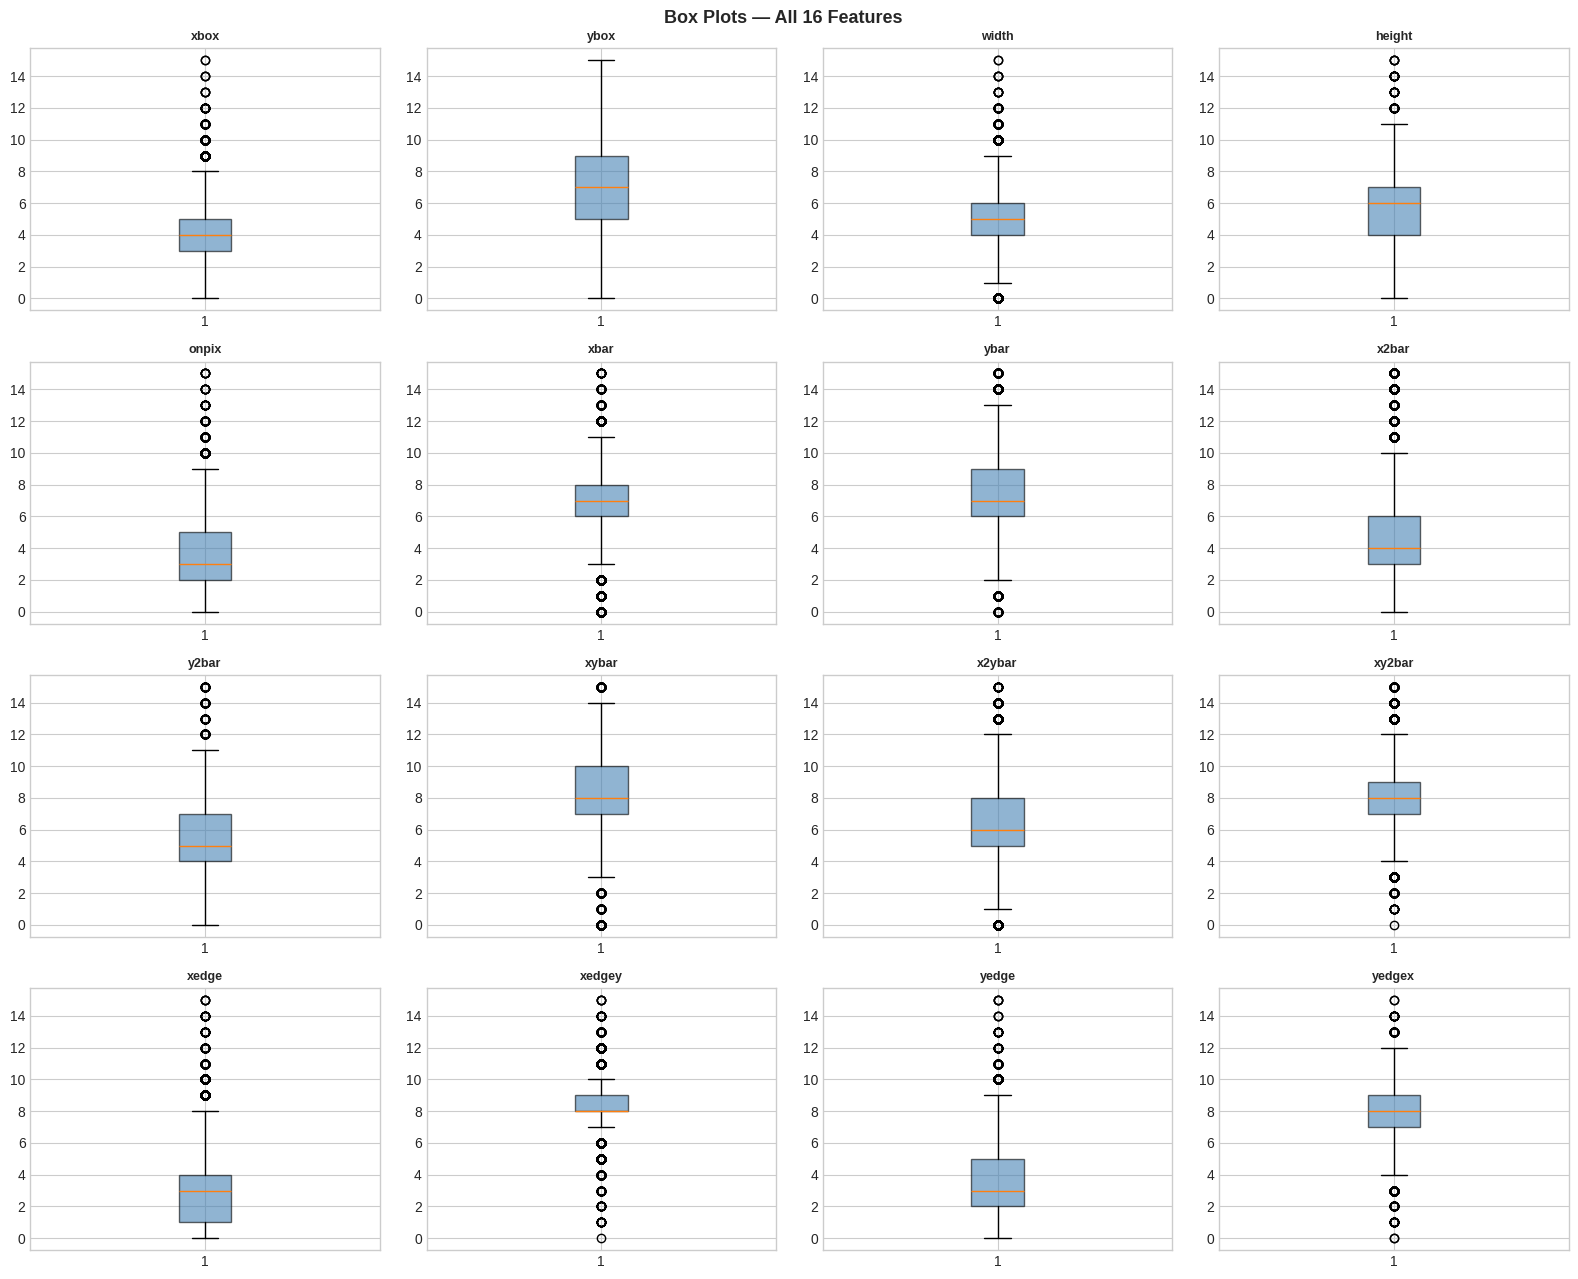

In [7]:
# --- Box plots ---
fig, axes = plt.subplots(4, 4, figsize=(16, 13))
axes = axes.flatten()
for i, col in enumerate(feature_cols):
    axes[i].boxplot(df[col], patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[i].set_title(col, fontsize=9, fontweight='bold')
plt.suptitle('Box Plots — All 16 Features',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

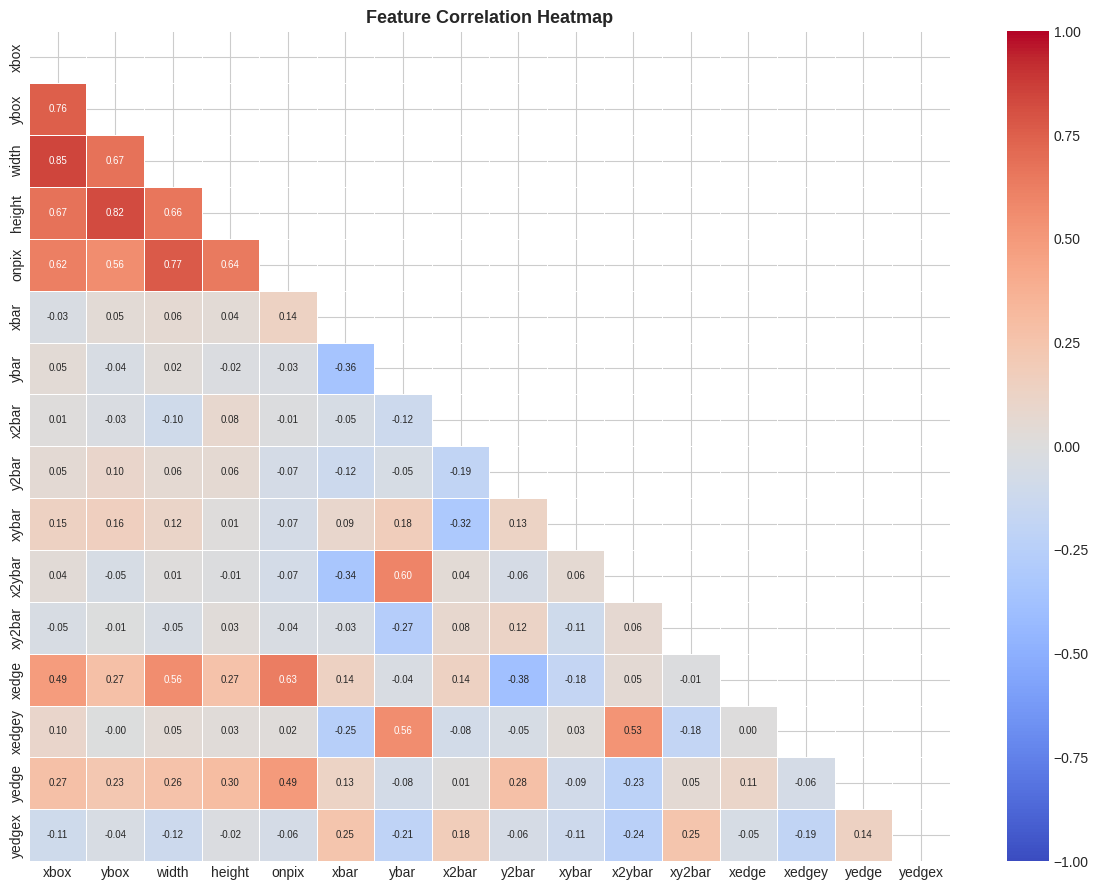

In [8]:
# --- Correlation heatmap ---
corr = df[feature_cols].corr()
plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.4,
            vmin=-1, vmax=1, annot_kws={'size': 7})
plt.title('Feature Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

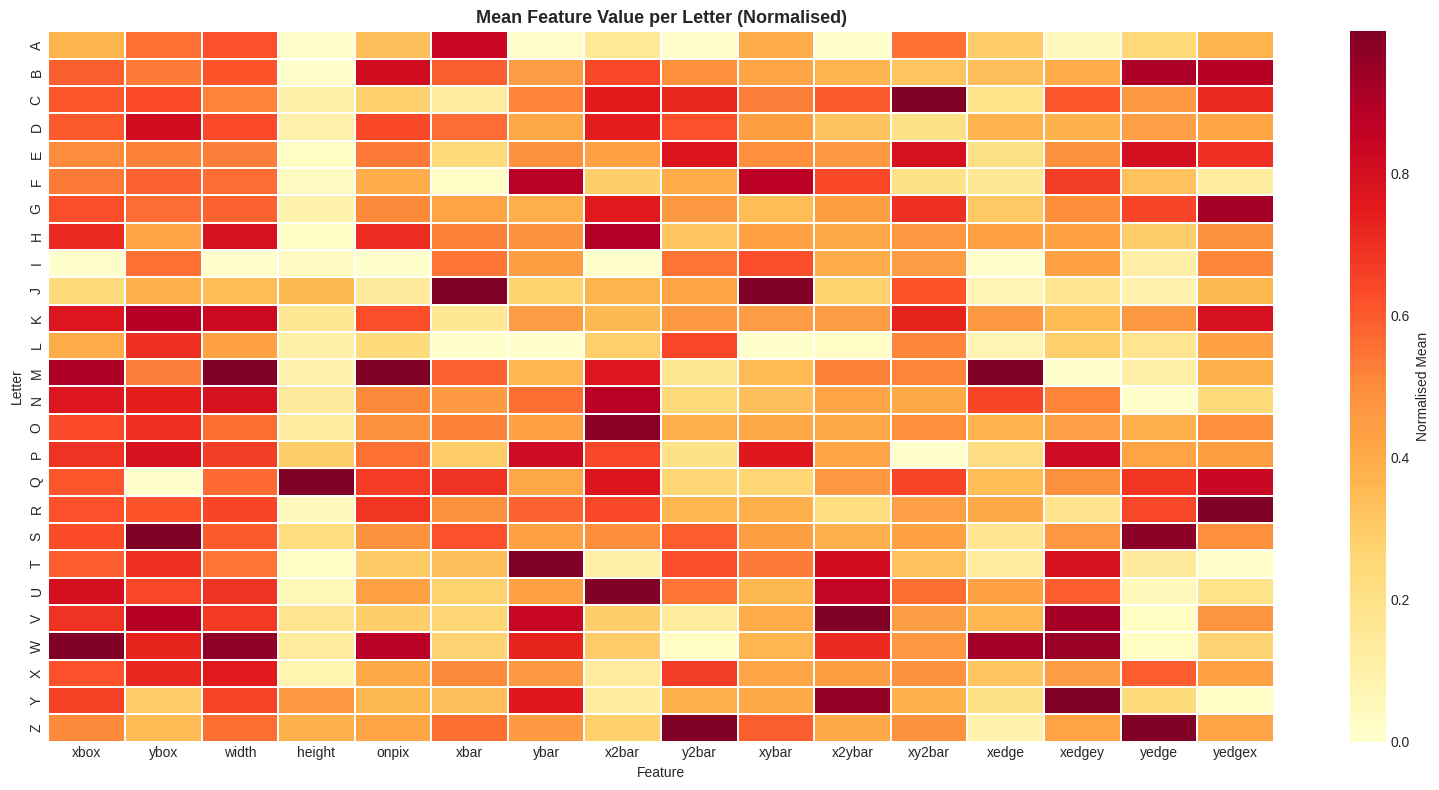

In [9]:
# --- Mean feature value per letter ---
feat_by_letter = df.groupby('letter')[feature_cols].mean()
feat_norm = (feat_by_letter - feat_by_letter.min()) / \
            (feat_by_letter.max() - feat_by_letter.min() + 1e-8)

plt.figure(figsize=(16, 8))
sns.heatmap(feat_norm, cmap='YlOrRd', linewidths=0.2,
            annot=False, cbar_kws={'label': 'Normalised Mean'})
plt.title('Mean Feature Value per Letter (Normalised)',
          fontsize=13, fontweight='bold')
plt.xlabel('Feature')
plt.ylabel('Letter')
plt.tight_layout()
plt.show()

### 1b. Preprocessing

In [10]:
# Separate features and target
X = df[feature_cols].values.astype(np.float32)
y_raw = df['letter'].values

# Label encode: A=0, B=1, ..., Z=25
le = LabelEncoder()
y_enc = le.fit_transform(y_raw)
y_cat = to_categorical(y_enc, num_classes=26)   # one-hot for ANN

print('Label encoding (A→Z = 0→25):')
print(dict(zip(le.classes_, range(26))))
print(f'\nX shape     : {X.shape}')
print(f'y_enc shape : {y_enc.shape}')
print(f'y_cat shape : {y_cat.shape}  (one-hot encoded)')

Label encoding (A→Z = 0→25):
{'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6, 'H': 7, 'I': 8, 'J': 9, 'K': 10, 'L': 11, 'M': 12, 'N': 13, 'O': 14, 'P': 15, 'Q': 16, 'R': 17, 'S': 18, 'T': 19, 'U': 20, 'V': 21, 'W': 22, 'X': 23, 'Y': 24, 'Z': 25}

X shape     : (20000, 16)
y_enc shape : (20000,)
y_cat shape : (20000, 26)  (one-hot encoded)


In [11]:
# Train/Test split (80/20 stratified) BEFORE scaling — avoids leakage
X_train_raw, X_test_raw, y_train_enc, y_test_enc, \
    y_train_cat, y_test_cat = train_test_split(
        X, y_enc, y_cat,
        test_size=0.2, random_state=SEED, stratify=y_enc
    )

# StandardScaler — fit only on train, transform both
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test  = scaler.transform(X_test_raw)

print(f'Train size  : {X_train.shape[0]:,}  (80%)')
print(f'Test  size  : {X_test.shape[0]:,}  (20%)')
print(f'Scaled range — min: {X_train.min():.3f}  max: {X_train.max():.3f}')
print('Preprocessing complete — StandardScaler applied (mean=0, std=1).')

Train size  : 16,000  (80%)
Test  size  : 4,000  (20%)
Scaled range — min: -5.359  max: 5.758
Preprocessing complete — StandardScaler applied (mean=0, std=1).


---
## Task 2 — Baseline ANN Model

In [12]:
def build_baseline(input_dim=16, n_classes=26):
    """Basic ANN: Input → Dense(64,relu) → Dense(32,relu) → Output."""
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(n_classes, activation='softmax')
    ], name='Baseline_ANN')
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

baseline = build_baseline()
baseline.summary()

Model: "Baseline_ANN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 26)             │           858 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,026 (15.73 KB)

 Trainable params: 4,026 (15.73 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# Train baseline
cb_base = EarlyStopping(monitor='val_loss', patience=10,
                        restore_best_weights=True, verbose=0)
history_base = baseline.fit(
    X_train, y_train_cat,
    epochs=100, batch_size=64,
    validation_split=0.15,
    callbacks=[cb_base], verbose=1
)
print('Baseline training complete.')

Epoch 1/100


  1/213 ━━━━━━━━━━━━━━━━━━━━ 6:05 2s/step - accuracy: 0.0625 - loss: 3.3885

 16/213 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0599 - loss: 3.3249 

 51/213 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0872 - loss: 3.2275

 52/213 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0880 - loss: 3.2252

...

151/213 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9873 - loss: 0.0505

152/213 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9873 - loss: 0.0505

187/213 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9871 - loss: 0.0507

213/213 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9868 - loss: 0.0509 - val_accuracy: 0.9454 - val_loss: 0.2055


Baseline training complete.


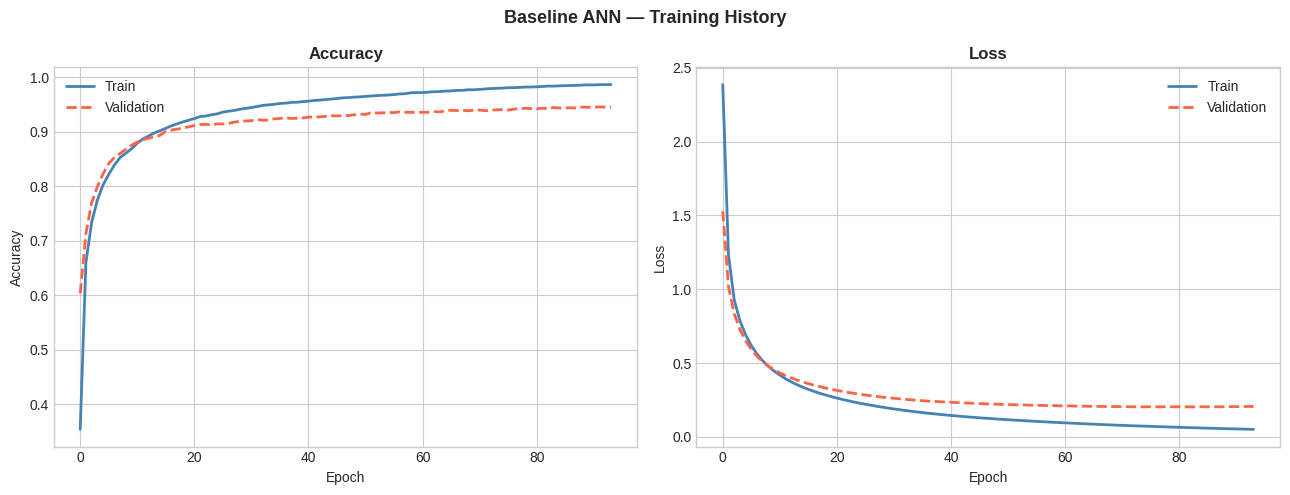

In [14]:
def plot_history(history, title):
    """Plot accuracy and loss curves side by side."""
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    axes[0].plot(history.history['accuracy'],
                 color='steelblue', linewidth=2, label='Train')
    axes[0].plot(history.history['val_accuracy'],
                 color='tomato', linewidth=2,
                 linestyle='--', label='Validation')
    axes[0].set_title('Accuracy', fontweight='bold')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[1].plot(history.history['loss'],
                 color='steelblue', linewidth=2, label='Train')
    axes[1].plot(history.history['val_loss'],
                 color='tomato', linewidth=2,
                 linestyle='--', label='Validation')
    axes[1].set_title('Loss', fontweight='bold')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
    axes[1].legend()
    plt.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

plot_history(history_base, 'Baseline ANN — Training History')

In [15]:
def evaluate_ann(model, X_te, y_te_enc, y_te_cat, label):
    """Evaluate model, print metrics, return results dict."""
    y_pred = np.argmax(model.predict(X_te, verbose=0), axis=1)
    acc  = accuracy_score(y_te_enc, y_pred)
    prec = precision_score(y_te_enc, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_te_enc, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_te_enc, y_pred, average='weighted', zero_division=0)
    print(f'{'='*52}')
    print(f'  {label}')
    print(f'{'='*52}')
    print(f'  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)')
    print(f'  Precision : {prec:.4f}  (weighted avg)')
    print(f'  Recall    : {rec:.4f}  (weighted avg)')
    print(f'  F1-Score  : {f1:.4f}  (weighted avg)')
    print()
    return {'Model': label, 'Accuracy': acc, 'Precision': prec,
            'Recall': rec, 'F1': f1, 'y_pred': y_pred}

res_base = evaluate_ann(baseline, X_test, y_test_enc,
                        y_test_cat, 'Baseline ANN  (64→32)')

  Baseline ANN  (64→32)
  Accuracy  : 0.9390  (93.90%)
  Precision : 0.9401  (weighted avg)
  Recall    : 0.9390  (weighted avg)
  F1-Score  : 0.9392  (weighted avg)



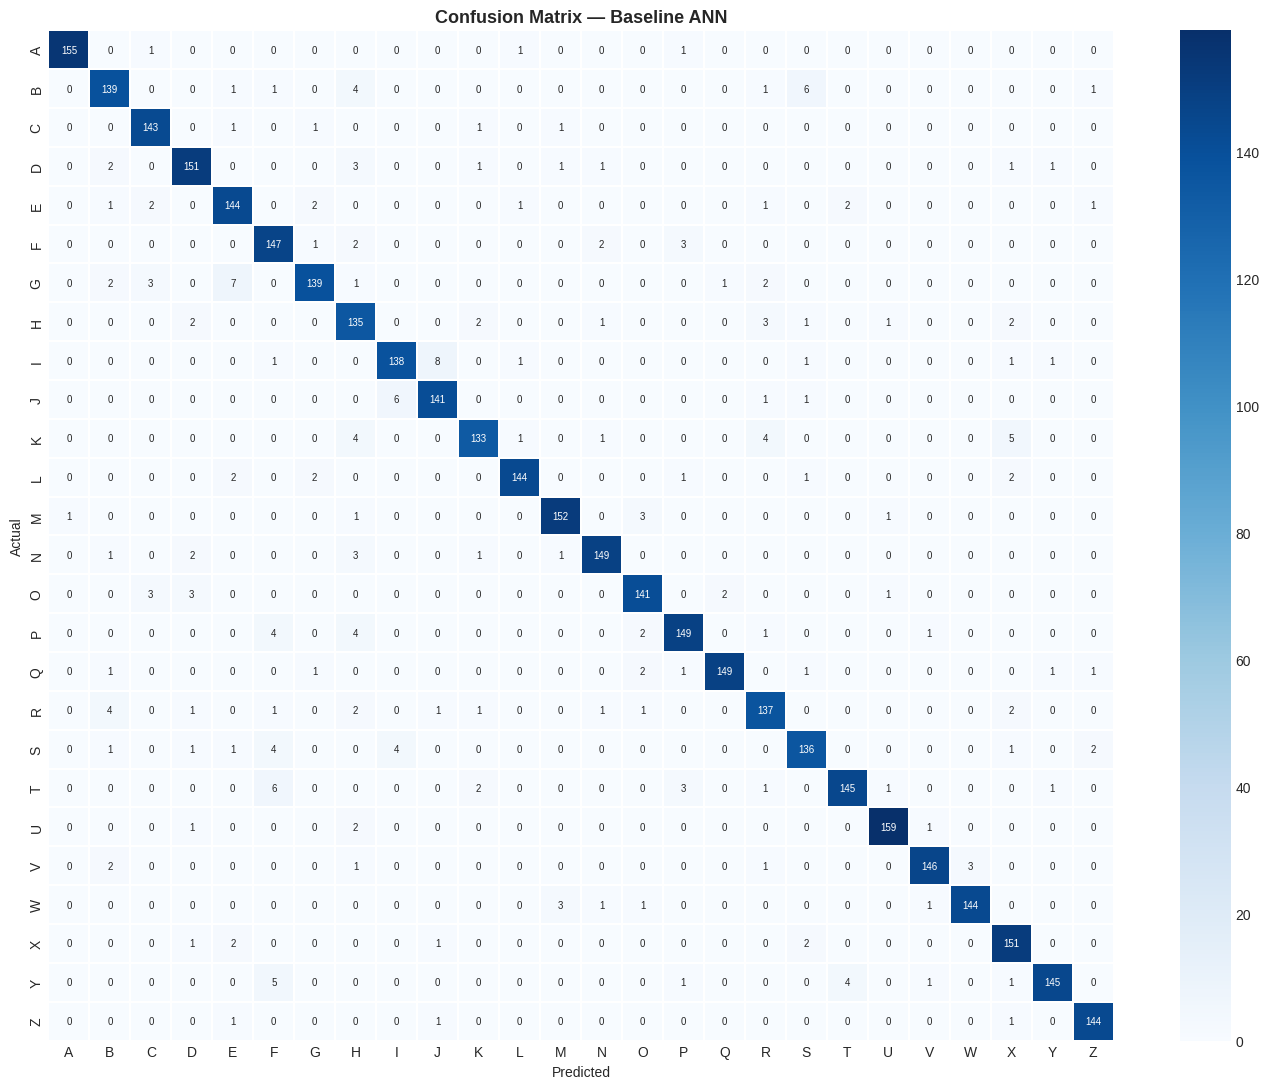

In [16]:
# Baseline confusion matrix
cm_base = confusion_matrix(y_test_enc, res_base['y_pred'])
plt.figure(figsize=(14, 11))
sns.heatmap(cm_base, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_,
            linewidths=0.3, annot_kws={'size': 7})
plt.title('Confusion Matrix — Baseline ANN',
          fontsize=13, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

---
## Task 3 — Hyperparameter Tuning (Grid Search)

In [17]:
# Hyperparameter grid
# Tuning: architecture, activation, learning rate, dropout, batch size
param_grid = [
    # (architecture,       activation, lr,     dropout, batch)
    ([128, 64],           'relu',    0.001,  0.0,     64),   # Config 1
    ([256, 128, 64],      'relu',    0.001,  0.2,     64),   # Config 2
    ([128, 64, 32],       'tanh',    0.001,  0.2,     64),   # Config 3
    ([256, 128, 64, 32],  'relu',    0.0005, 0.3,     32),   # Config 4
    ([512, 256, 128],     'relu',    0.001,  0.25,    64),   # Config 5
]

print('Hyperparameter Grid (Manual Grid Search):')
print(f'{"Config":<8} {"Architecture":<22} {"Activation":<10} '
      f'{"LR":<8} {"Dropout":<9} {"Batch"}')
print('-' * 68)
for i, (a, act, lr, dr, bs) in enumerate(param_grid, 1):
    print(f'{i:<8} {str(a):<22} {act:<10} {lr:<8} {dr:<9} {bs}')

Hyperparameter Grid (Manual Grid Search):
Config   Architecture           Activation LR       Dropout   Batch
--------------------------------------------------------------------
1        [128, 64]              relu       0.001    0.0       64
2        [256, 128, 64]         relu       0.001    0.2       64
3        [128, 64, 32]          tanh       0.001    0.2       64
4        [256, 128, 64, 32]     relu       0.0005   0.3       32
5        [512, 256, 128]        relu       0.001    0.25      64


In [18]:
def build_tuned(arch, activation, lr, dropout,
                n_classes=26, input_dim=16):
    """Build configurable ANN with L2 regularisation and optional Dropout."""
    model = keras.Sequential(name='Tuned_ANN')
    model.add(layers.Input(shape=(input_dim,)))
    for units in arch:
        model.add(layers.Dense(
            units, activation=activation,
            kernel_regularizer=regularizers.l2(1e-4)
        ))
        if dropout > 0:
            model.add(layers.Dropout(dropout))
    model.add(layers.Dense(n_classes, activation='softmax'))
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Run grid search
grid_results = []
best_val_acc = 0
best_params  = None
best_history = None
best_grid_model = None

cb_grid = EarlyStopping(monitor='val_accuracy', patience=8,
                        restore_best_weights=True, verbose=0)

for idx, (arch, act, lr, dr, bs) in enumerate(param_grid):
    print(f'Config {idx+1}/{len(param_grid)}: '
          f'arch={arch} act={act} lr={lr} dropout={dr} batch={bs}',
          end=' ... ')
    m = build_tuned(arch, act, lr, dr)
    h = m.fit(
        X_train, y_train_cat,
        epochs=80, batch_size=bs,
        validation_split=0.15,
        callbacks=[cb_grid], verbose=0
    )
    val_acc   = max(h.history['val_accuracy'])
    train_acc = max(h.history['accuracy'])
    epochs_run = len(h.history['accuracy'])
    print(f'val_acc={val_acc:.4f}  epochs={epochs_run}')
    grid_results.append({
        'Config'     : idx+1,
        'Arch'       : str(arch),
        'Activation' : act,
        'LR'         : lr,
        'Dropout'    : dr,
        'Batch'      : bs,
        'Train_Acc'  : round(train_acc, 4),
        'Val_Acc'    : round(val_acc, 4),
        'Epochs'     : epochs_run
    })
    if val_acc > best_val_acc:
        best_val_acc    = val_acc
        best_params     = (arch, act, lr, dr, bs)
        best_history    = h
        best_grid_model = m

grid_df = pd.DataFrame(grid_results)
print(f'\nBest Config → arch={best_params[0]} act={best_params[1]} '
      f'lr={best_params[2]} dropout={best_params[3]} '
      f'batch={best_params[4]}')
print(f'Best Val Accuracy : {best_val_acc:.4f}')

Config 1/5: arch=[128, 64] act=relu lr=0.001 dropout=0.0 batch=64 ... 

val_acc=0.9529  epochs=59
Config 2/5: arch=[256, 128, 64] act=relu lr=0.001 dropout=0.2 batch=64 ... 

val_acc=0.9029  epochs=8
Config 3/5: arch=[128, 64, 32] act=tanh lr=0.001 dropout=0.2 batch=64 ... 

val_acc=0.8183  epochs=8
Config 4/5: arch=[256, 128, 64, 32] act=relu lr=0.0005 dropout=0.3 batch=32 ... 

val_acc=0.8208  epochs=8
Config 5/5: arch=[512, 256, 128] act=relu lr=0.001 dropout=0.25 batch=64 ... 

val_acc=0.9367  epochs=8

Best Config → arch=[128, 64] act=relu lr=0.001 dropout=0.0 batch=64
Best Val Accuracy : 0.9529


In [19]:
# Grid search results table
print('Grid Search Results:')
grid_df.sort_values('Val_Acc', ascending=False)

Grid Search Results:


,Config,Arch,Activation,LR,Dropout,Batch,Train_Acc,Val_Acc,Epochs
0,1,"[128, 64]",relu,0.0010,0.00,64,0.9954,0.9529,59
4,5,"[512, 256, 128]",relu,0.0010,0.25,64,0.8984,0.9367,8
1,2,"[256, 128, 64]",relu,0.0010,0.20,64,0.8415,0.9029,8
3,4,"[256, 128, 64, 32]",relu,0.0005,0.30,32,0.6738,0.8208,8
2,3,"[128, 64, 32]",tanh,0.0010,0.20,64,0.7368,0.8183,8


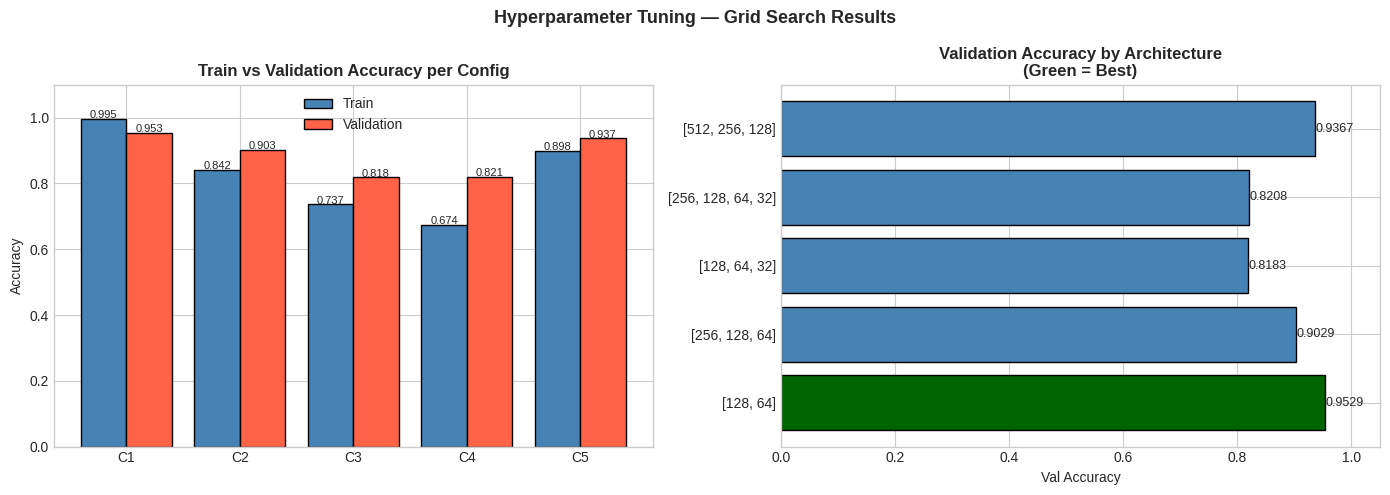

In [20]:
# Grid search visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x_pos  = np.arange(len(grid_df))
cfg_labels = [f'C{r}' for r in grid_df['Config']]

# Train vs Val accuracy per config
axes[0].bar(x_pos - 0.2, grid_df['Train_Acc'], 0.4,
            label='Train', color='steelblue', edgecolor='black')
axes[0].bar(x_pos + 0.2, grid_df['Val_Acc'], 0.4,
            label='Validation', color='tomato', edgecolor='black')
for i, (ta, va) in enumerate(zip(grid_df['Train_Acc'],
                                  grid_df['Val_Acc'])):
    axes[0].text(i-0.2, ta+0.002, f'{ta:.3f}', ha='center', fontsize=8)
    axes[0].text(i+0.2, va+0.002, f'{va:.3f}', ha='center', fontsize=8)
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(cfg_labels)
axes[0].set_title('Train vs Validation Accuracy per Config',
                  fontweight='bold')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0, 1.1)
axes[0].legend()

# Val accuracy by architecture
bar_colors = ['darkgreen' if v == grid_df['Val_Acc'].max()
              else 'steelblue' for v in grid_df['Val_Acc']]
axes[1].barh(grid_df['Arch'], grid_df['Val_Acc'],
             color=bar_colors, edgecolor='black')
for i, v in enumerate(grid_df['Val_Acc']):
    axes[1].text(v+0.001, i, f'{v:.4f}', va='center', fontsize=9)
axes[1].set_title('Validation Accuracy by Architecture\n(Green = Best)',
                  fontweight='bold')
axes[1].set_xlabel('Val Accuracy')
axes[1].set_xlim(0, 1.05)

plt.suptitle('Hyperparameter Tuning — Grid Search Results',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

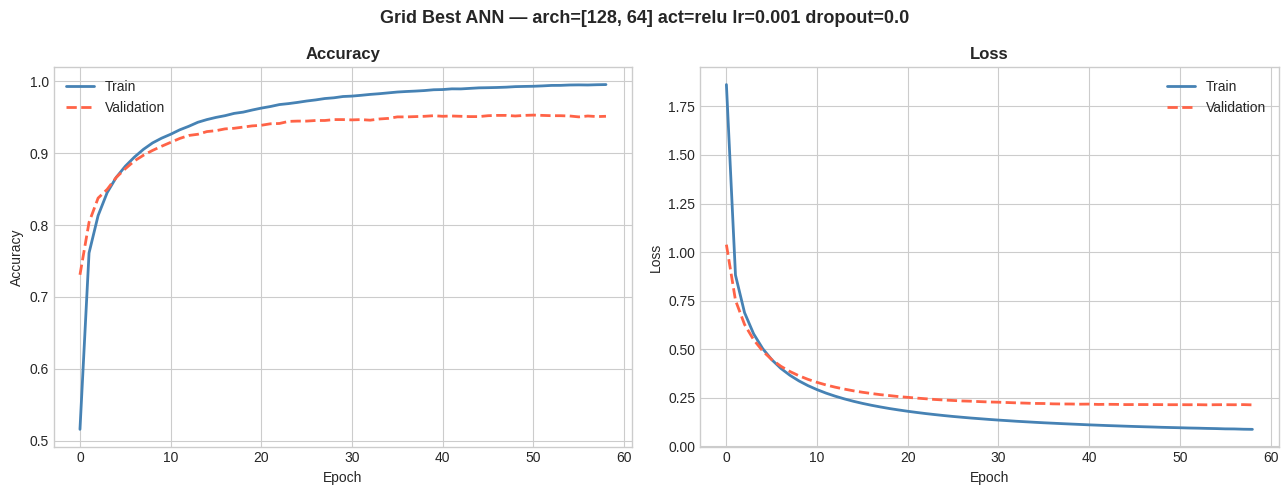

In [21]:
plot_history(best_history,
    f'Grid Best ANN — arch={best_params[0]} '
    f'act={best_params[1]} lr={best_params[2]} dropout={best_params[3]}')

### Final Deep ANN — Best Architecture with BatchNorm + ReduceLROnPlateau

In [22]:
def build_final_model(n_classes=26, input_dim=16):
    """Deep ANN: 512→256→128→64 with BatchNorm, Dropout, L2."""
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),

        layers.Dense(512, activation='relu',
                     kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.Dense(256, activation='relu',
                     kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.Dense(128, activation='relu',
                     kernel_regularizer=regularizers.l2(1e-4)),
        layers.Dropout(0.2),

        layers.Dense(64, activation='relu'),
        layers.Dense(n_classes, activation='softmax')
    ], name='Final_Tuned_ANN')

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

final_model = build_final_model()
final_model.summary()

Model: "Final_Tuned_ANN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_23 (Dense)                │ (None, 512)            │         8,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 26)             │         1,690 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 185,946 (726.35 KB)

 Trainable params: 184,410 (720.35 KB)

 Non-trainable params: 1,536 (6.00 KB)

In [23]:
callbacks_final = [
    EarlyStopping(monitor='val_accuracy', patience=12,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                     patience=5, min_lr=1e-6, verbose=1)
]

history_final = final_model.fit(
    X_train, y_train_cat,
    epochs=150, batch_size=64,
    validation_split=0.15,
    callbacks=callbacks_final,
    verbose=1
)
print('Final model training complete.')

Epoch 1/150


  1/213 ━━━━━━━━━━━━━━━━━━━━ 15:50 4s/step - accuracy: 0.0938 - loss: 3.5099

 10/213 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.0778 - loss: 3.4655 

 20/213 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.1147 - loss: 3.3146

 28/213 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.1402 - loss: 3.2110

...

212/213 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9868 - loss: 0.1011

213/213 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.9888 - loss: 0.0971 - val_accuracy: 0.9771 - val_loss: 0.1415 - learning_rate: 1.5625e-05


Epoch 97: early stopping


Restoring model weights from the end of the best epoch: 85.


Final model training complete.


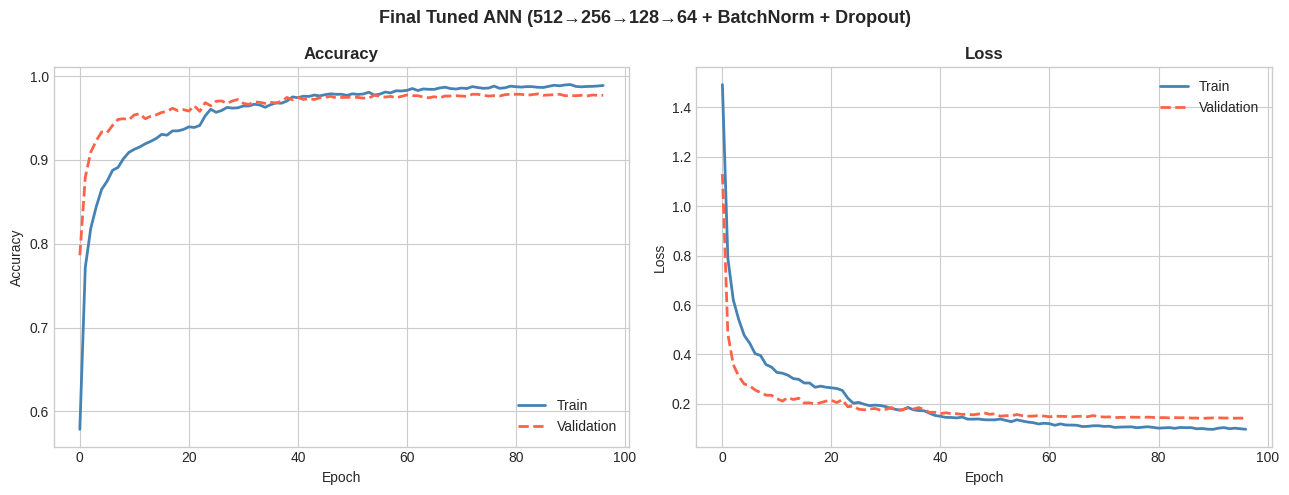

In [24]:
plot_history(history_final,
    'Final Tuned ANN (512→256→128→64 + BatchNorm + Dropout)')

---
## Task 4 — Evaluation & Comparison

In [25]:
# Evaluate all three models
res_base  = evaluate_ann(baseline, X_test, y_test_enc,
                         y_test_cat, 'Baseline ANN  (64→32)')
res_grid  = evaluate_ann(best_grid_model, X_test, y_test_enc,
                         y_test_cat, f'Grid Best  {best_params[0]}')
res_final = evaluate_ann(final_model, X_test, y_test_enc,
                         y_test_cat, 'Final Tuned  (512→256→128→64)')

  Baseline ANN  (64→32)
  Accuracy  : 0.9390  (93.90%)
  Precision : 0.9401  (weighted avg)
  Recall    : 0.9390  (weighted avg)
  F1-Score  : 0.9392  (weighted avg)



  Grid Best  [128, 64]
  Accuracy  : 0.9557  (95.58%)
  Precision : 0.9567  (weighted avg)
  Recall    : 0.9557  (weighted avg)
  F1-Score  : 0.9559  (weighted avg)



  Final Tuned  (512→256→128→64)
  Accuracy  : 0.9800  (98.00%)
  Precision : 0.9801  (weighted avg)
  Recall    : 0.9800  (weighted avg)
  F1-Score  : 0.9800  (weighted avg)



In [26]:
# Detailed classification report — Final model
print('Classification Report — Final Tuned ANN:')
print(classification_report(
    y_test_enc, res_final['y_pred'],
    target_names=le.classes_, zero_division=0
))

Classification Report — Final Tuned ANN:
              precision    recall  f1-score   support

           A       1.00      1.00      1.00       158
           B       0.95      0.95      0.95       153
           C       0.99      1.00      1.00       147
           D       0.99      0.99      0.99       161
           E       0.98      0.98      0.98       154
           F       0.99      0.97      0.98       155
           G       0.97      0.97      0.97       155
           H       0.93      0.95      0.94       147
           I       0.95      0.95      0.95       151
           J       0.97      0.95      0.96       149
           K       0.95      0.96      0.96       148
           L       0.99      0.99      0.99       152
           M       1.00      0.99      0.99       158
           N       1.00      0.96      0.98       157
           O       0.97      0.99      0.98       150
           P       0.98      0.98      0.98       161
           Q       0.99      0.99      0

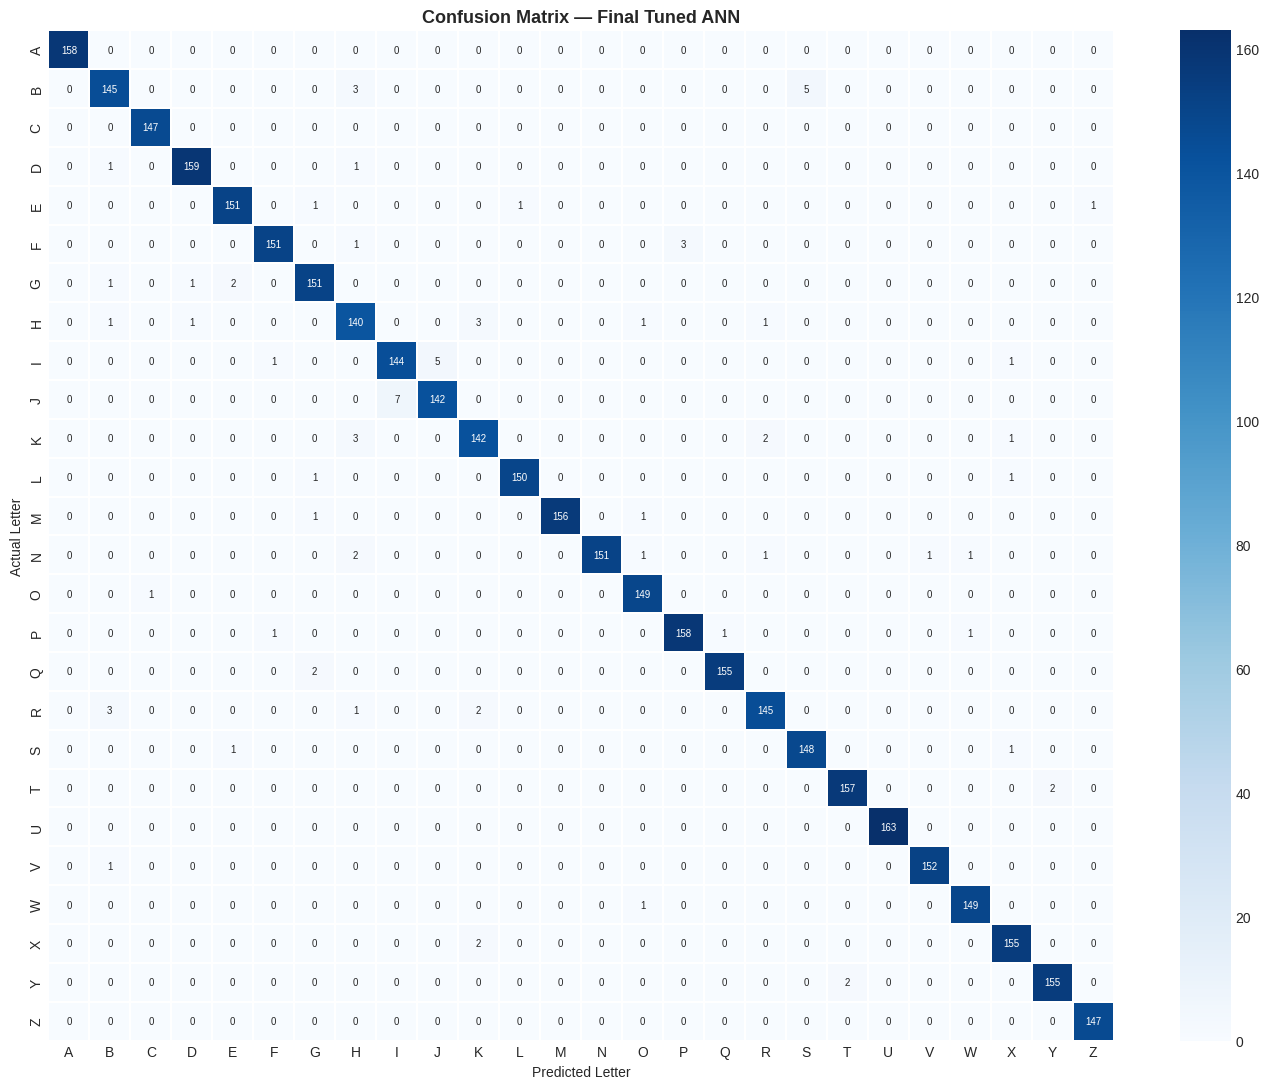

In [27]:
# Confusion matrix — Final model
cm_final = confusion_matrix(y_test_enc, res_final['y_pred'])
plt.figure(figsize=(14, 11))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_,
            linewidths=0.3, annot_kws={'size': 7})
plt.title('Confusion Matrix — Final Tuned ANN',
          fontsize=13, fontweight='bold')
plt.xlabel('Predicted Letter')
plt.ylabel('Actual Letter')
plt.tight_layout()
plt.show()

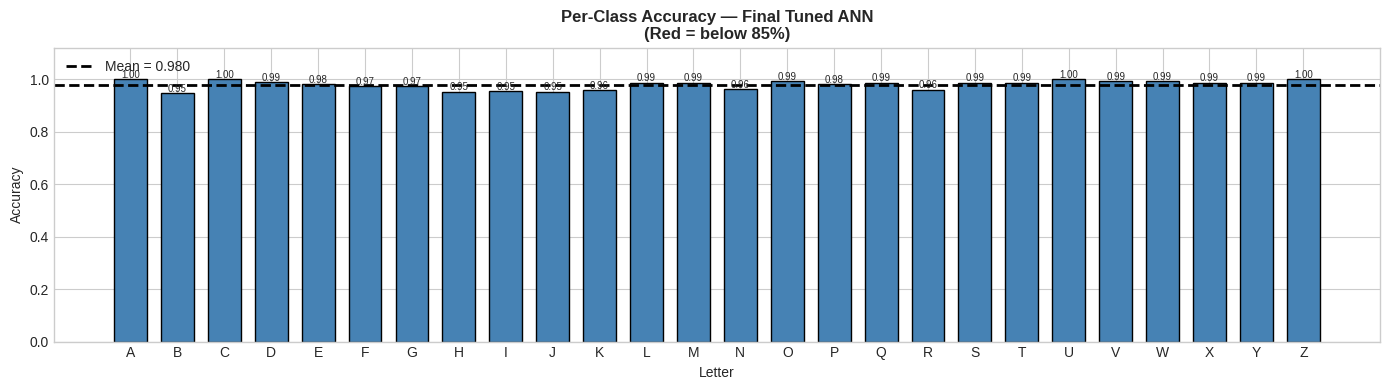

In [28]:
# Per-class accuracy — Final model
per_class_acc = cm_final.diagonal() / cm_final.sum(axis=1)

plt.figure(figsize=(14, 4))
bar_cols = ['tomato' if v < 0.85 else 'steelblue'
            for v in per_class_acc]
bars = plt.bar(le.classes_, per_class_acc,
               color=bar_cols, edgecolor='black', width=0.7)
plt.axhline(per_class_acc.mean(), color='black', linestyle='--',
            linewidth=2, label=f'Mean = {per_class_acc.mean():.3f}')
for bar, v in zip(bars, per_class_acc):
    plt.text(bar.get_x()+bar.get_width()/2,
             bar.get_height()+0.005, f'{v:.2f}',
             ha='center', fontsize=7)
plt.title('Per-Class Accuracy — Final Tuned ANN\n'
          '(Red = below 85%)', fontweight='bold')
plt.ylabel('Accuracy')
plt.xlabel('Letter')
plt.ylim(0, 1.12)
plt.legend()
plt.tight_layout()
plt.show()

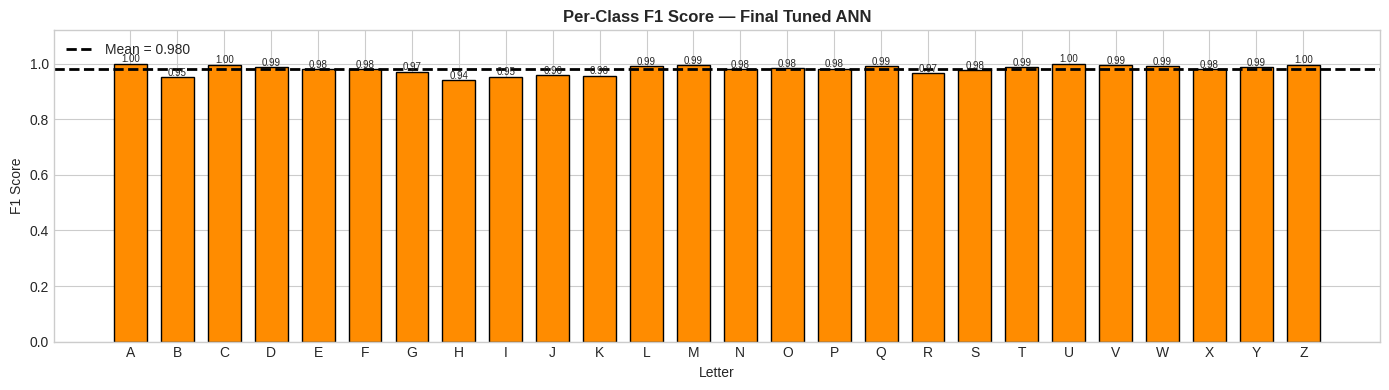

In [29]:
# Per-class F1 — Final model
f1_per = f1_score(y_test_enc, res_final['y_pred'],
                  average=None, zero_division=0)
plt.figure(figsize=(14, 4))
bar_f1 = ['tomato' if v < 0.85 else 'darkorange' for v in f1_per]
bars = plt.bar(le.classes_, f1_per,
               color=bar_f1, edgecolor='black', width=0.7)
plt.axhline(f1_per.mean(), color='black', linestyle='--',
            linewidth=2, label=f'Mean = {f1_per.mean():.3f}')
for bar, v in zip(bars, f1_per):
    plt.text(bar.get_x()+bar.get_width()/2,
             bar.get_height()+0.005, f'{v:.2f}',
             ha='center', fontsize=7)
plt.title('Per-Class F1 Score — Final Tuned ANN',
          fontweight='bold')
plt.ylabel('F1 Score')
plt.xlabel('Letter')
plt.ylim(0, 1.12)
plt.legend()
plt.tight_layout()
plt.show()

In [30]:
# Model comparison table
compare_df = pd.DataFrame([
    {k: v for k, v in r.items() if k != 'y_pred'}
    for r in [res_base, res_grid, res_final]
]).round(4)
print('Model Comparison Table:')
compare_df

Model Comparison Table:


,Model,Accuracy,Precision,Recall,F1
0,Baseline ANN (64→32),0.9390,0.9401,0.9390,0.9392
1,"Grid Best [128, 64]",0.9558,0.9567,0.9558,0.9559
2,Final Tuned (512→256→128→64),0.9800,0.9801,0.9800,0.9800


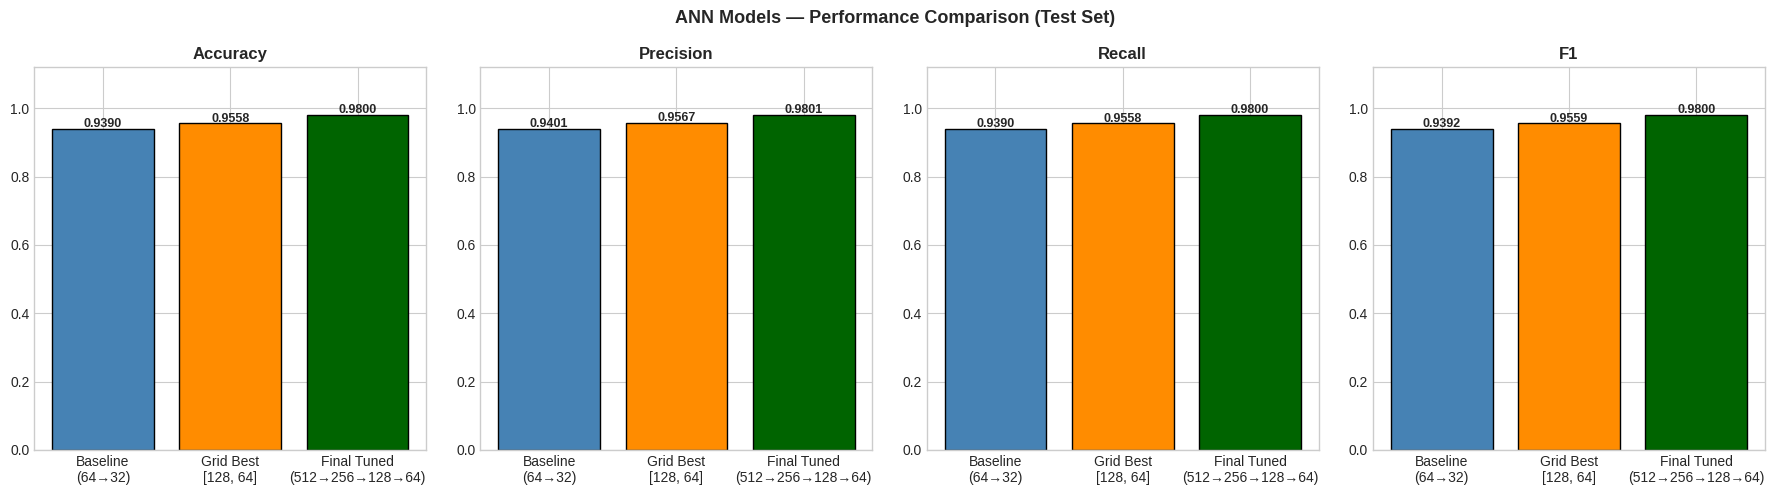

In [31]:
# Comparison bar chart — all metrics
short_names = ['Baseline\n(64→32)',
               f'Grid Best\n{best_params[0]}',
               'Final Tuned\n(512→256→128→64)']
bar_clrs = ['steelblue', 'darkorange', 'darkgreen']
metrics  = ['Accuracy', 'Precision', 'Recall', 'F1']

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, metric in zip(axes, metrics):
    vals = compare_df[metric].values
    bars = ax.bar(short_names, vals,
                  color=bar_clrs, edgecolor='black')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height()+0.005, f'{v:.4f}',
                ha='center', fontweight='bold', fontsize=9)
    ax.set_title(metric, fontweight='bold')
    ax.set_ylim(0, 1.12)
    ax.tick_params(axis='x', rotation=0)

plt.suptitle('ANN Models — Performance Comparison (Test Set)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

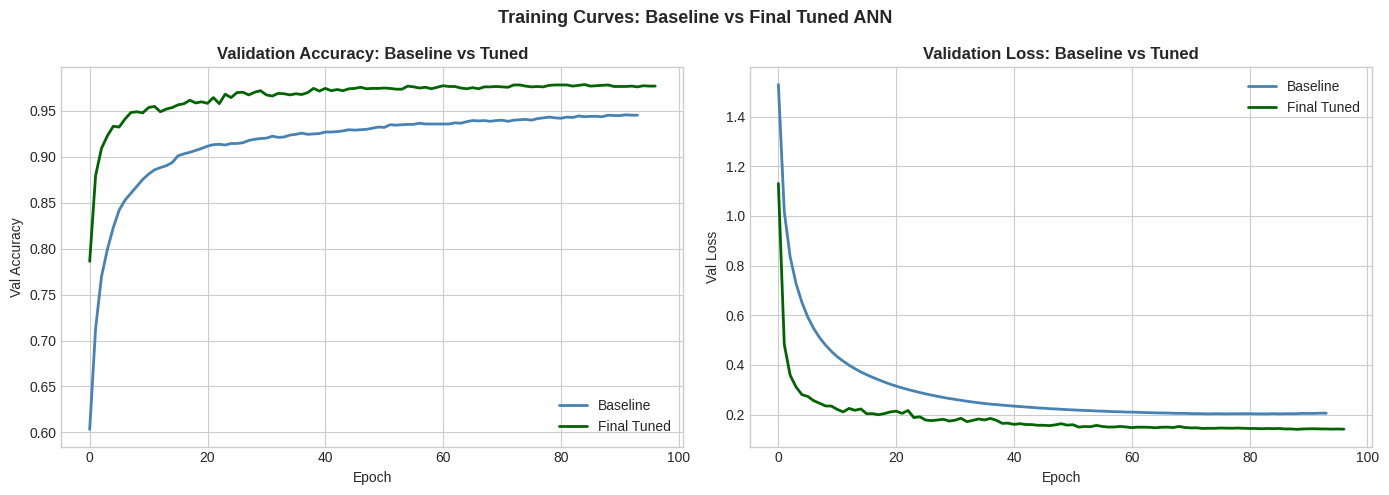

In [32]:
# Learning curves overlay — Baseline vs Final
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_base.history['val_accuracy'],
             color='steelblue', linewidth=2, label='Baseline')
axes[0].plot(history_final.history['val_accuracy'],
             color='darkgreen', linewidth=2, label='Final Tuned')
axes[0].set_title('Validation Accuracy: Baseline vs Tuned',
                  fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Val Accuracy')
axes[0].legend()

axes[1].plot(history_base.history['val_loss'],
             color='steelblue', linewidth=2, label='Baseline')
axes[1].plot(history_final.history['val_loss'],
             color='darkgreen', linewidth=2, label='Final Tuned')
axes[1].set_title('Validation Loss: Baseline vs Tuned',
                  fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Val Loss')
axes[1].legend()

plt.suptitle('Training Curves: Baseline vs Final Tuned ANN',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [33]:
# Hyperparameter effect discussion
base_acc  = compare_df.loc[0, 'Accuracy']
final_acc = compare_df.loc[2, 'Accuracy']
gain      = (final_acc - base_acc) * 100

print('='*65)
print('HYPERPARAMETER TUNING — IMPACT DISCUSSION')
print('='*65)
print(f'  Baseline Accuracy     : {base_acc:.4f}  ({base_acc*100:.2f}%)')
print(f'  Final Tuned Accuracy  : {final_acc:.4f}  ({final_acc*100:.2f}%)')
print(f'  Accuracy Gain         : +{gain:.2f} percentage points')
print()
print('  Effect of Each Hyperparameter:')
print()
print('  Neurons per Layer  → More neurons = richer feature representations')
print('    Baseline used 64→32; Final uses 512→256→128→64')
print('    Result: model captures finer distinctions between similar letters')
print()
print('  Hidden Layers      → Deeper networks learn hierarchical patterns')
print('    Extra layers help separate visually similar letters (e.g. C/G, I/J)')
print()
print('  Dropout (0.2–0.3)  → Prevents co-adaptation of neurons')
print('    Reduces overfitting; val_accuracy closer to train_accuracy')
print()
print('  BatchNormalization → Normalises layer activations during training')
print('    Stabilises gradients, allows higher learning rate, faster convergence')
print()
print('  ReduceLROnPlateau  → Halves LR when val_loss stagnates')
print('    Fine-tunes weights near convergence; avoids overshooting minima')
print()
print('  EarlyStopping      → Stops training when val_accuracy stops improving')
print('    Saves best weights automatically; prevents overfitting')
print('='*65)

HYPERPARAMETER TUNING — IMPACT DISCUSSION
  Baseline Accuracy     : 0.9390  (93.90%)
  Final Tuned Accuracy  : 0.9800  (98.00%)
  Accuracy Gain         : +4.10 percentage points

  Effect of Each Hyperparameter:

  Neurons per Layer  → More neurons = richer feature representations
    Baseline used 64→32; Final uses 512→256→128→64
    Result: model captures finer distinctions between similar letters

  Hidden Layers      → Deeper networks learn hierarchical patterns
    Extra layers help separate visually similar letters (e.g. C/G, I/J)

  Dropout (0.2–0.3)  → Prevents co-adaptation of neurons
    Reduces overfitting; val_accuracy closer to train_accuracy

  BatchNormalization → Normalises layer activations during training
    Stabilises gradients, allows higher learning rate, faster convergence

  ReduceLROnPlateau  → Halves LR when val_loss stagnates
    Fine-tunes weights near convergence; avoids overshooting minima

  EarlyStopping      → Stops training when val_accuracy stops impr

In [34]:
# Final summary
print('='*65)
print('FINAL SUMMARY — ALPHABET CLASSIFICATION (ANN)')
print('='*65)
print(f'  Dataset         : Alphabets_data.csv')
print(f'  Samples         : 20,000  |  Features: 16  |  Classes: 26')
print(f'  Train / Test    : 16,000 / 4,000  (stratified split)')
print(f'  Normalisation   : StandardScaler (μ=0, σ=1)')
print(f'  Target Encoding : LabelEncoder + to_categorical (one-hot)')
print()
print('  Models Trained:')
for _, row in compare_df.iterrows():
    print(f"    {row['Model']:<40} Acc={row['Accuracy']:.4f}  "
          f"F1={row['F1']:.4f}")
print()
best_row = compare_df.loc[compare_df['Accuracy'].idxmax()]
print(f"  Best Model      : {best_row['Model']}")
print(f"  Best Accuracy   : {best_row['Accuracy']:.4f} "
      f"({best_row['Accuracy']*100:.2f}%)")
print('='*65)

FINAL SUMMARY — ALPHABET CLASSIFICATION (ANN)
  Dataset         : Alphabets_data.csv
  Samples         : 20,000  |  Features: 16  |  Classes: 26
  Train / Test    : 16,000 / 4,000  (stratified split)
  Normalisation   : StandardScaler (μ=0, σ=1)
  Target Encoding : LabelEncoder + to_categorical (one-hot)

  Models Trained:
    Baseline ANN  (64→32)                    Acc=0.9390  F1=0.9392
    Grid Best  [128, 64]                     Acc=0.9558  F1=0.9559
    Final Tuned  (512→256→128→64)            Acc=0.9800  F1=0.9800

  Best Model      : Final Tuned  (512→256→128→64)
  Best Accuracy   : 0.9800 (98.00%)
